## Hypothesis Testing
**H0:** mu_ADHD(t) = mu_nonADHD(t)  
**H1:** mu_ADHD(t) ≠ mu_nonADHD(t)  

Flanker Task EEG — Channel FC1  
ADHD group: 12 subjects | Non-ADHD group: 39 subjects

## Imports

In [1]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Add HT/ to path for helper modules
sys.path.insert(0, str(Path('HT').resolve()))
from f_stat_two_sample import f_stat_two_sample
from l2_stat_two_sample import l2_stat_two_sample
from z_two_sample import z_two_sample

## Set current dir to project root dir

In [2]:
def find_project_root():
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())


## Setup

In [3]:
out_dir = Path("./HT/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

old_files = list(out_dir.glob("*.pdf")) + list(out_dir.glob("*.txt"))
for f in old_files:
    f.unlink()
print(f"Cleaned {len(old_files)} old output files.")


Cleaned 10 old output files.


## Load smoothed data and split by ADHD status

In [4]:
with open("./EDA/outputs/fd_smooth.pkl", "rb") as f:
    d = pickle.load(f)

coef_opt    = d["coef_opt"]       # (nbasis, n_subj)
basis       = d["basis"]
time_vec    = d["time_vec"]
subject_ids = d["subject_ids"]

print(f"Total subjects in fd_smooth: {len(subject_ids)}")

# Evaluate on fine grid
t_fine = np.linspace(time_vec[0], time_vec[-1], 501)
B_fine = basis.evaluate(t_fine).squeeze().T    # (501, nbasis)
Y_eval = B_fine @ coef_opt                     # (501, n_subj)


Total subjects in fd_smooth: 62


/tmp/ipykernel_2886198/412620029.py:13: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_fine = basis.evaluate(t_fine).squeeze().T    # (501, nbasis)


In [5]:
# ADHD group assignments
adhd_subs = [
    'sub-003', 'sub-008', 'sub-010', 'sub-013', 'sub-014', 'sub-025',
    'sub-033', 'sub-036', 'sub-060', 'sub-061', 'sub-065', 'sub-066'
]
nonadhd_subs = [
    'sub-001', 'sub-002', 'sub-004', 'sub-005', 'sub-006', 'sub-007',
    'sub-009', 'sub-011', 'sub-012', 'sub-016', 'sub-017', 'sub-019',
    'sub-021', 'sub-022', 'sub-024', 'sub-027', 'sub-028', 'sub-029',
    'sub-030', 'sub-031', 'sub-032', 'sub-034', 'sub-035', 'sub-037',
    'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043',
    'sub-046', 'sub-053', 'sub-055', 'sub-057', 'sub-059', 'sub-062',
    'sub-063', 'sub-064', 'sub-069'
]

adhd_idx    = [i for i, s in enumerate(subject_ids) if s in adhd_subs]
nonadhd_idx = [i for i, s in enumerate(subject_ids) if s in nonadhd_subs]

print(f"ADHD subjects found:     {len(adhd_idx)}")
print(f"Non-ADHD subjects found: {len(nonadhd_idx)}")

Y_adhd    = Y_eval[:, adhd_idx]     # (501, 12)
Y_nonadhd = Y_eval[:, nonadhd_idx]  # (501, 39)


ADHD subjects found:     12
Non-ADHD subjects found: 39


## Plot: ADHD vs Non-ADHD group comparison

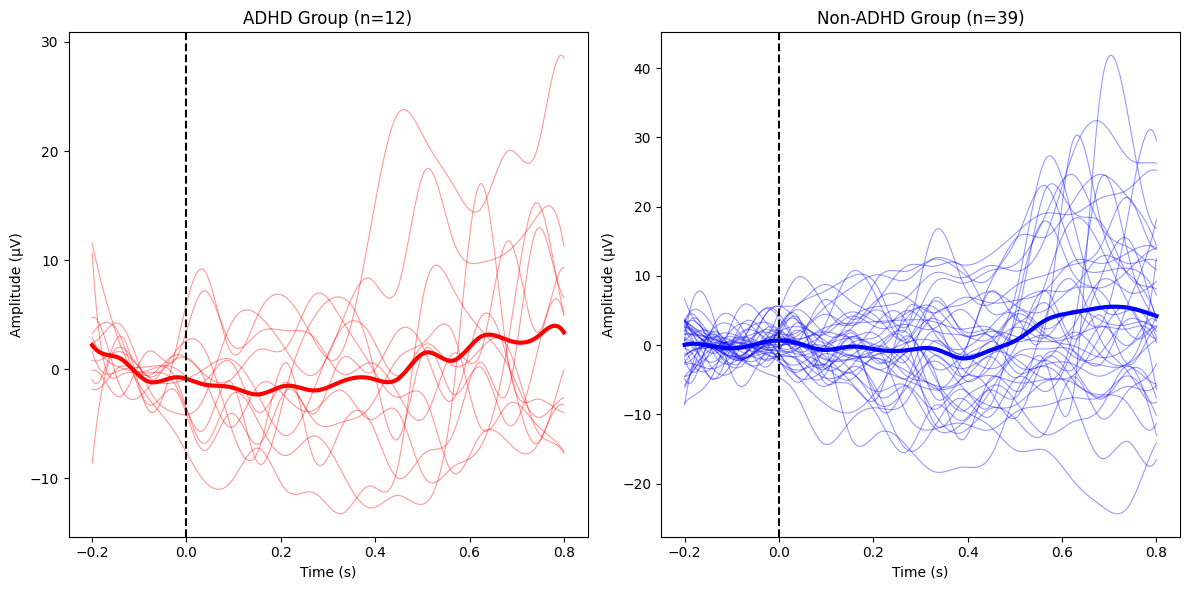

Saved: HT_01_group_comparison.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(t_fine, Y_adhd, color='red', alpha=0.4, linewidth=0.8)
axes[0].plot(t_fine, Y_adhd.mean(axis=1), color='red', linewidth=3)
axes[0].axvline(0, linestyle='--', color='black')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title(f'ADHD Group (n={len(adhd_idx)})')

axes[1].plot(t_fine, Y_nonadhd, color='blue', alpha=0.4, linewidth=0.8)
axes[1].plot(t_fine, Y_nonadhd.mean(axis=1), color='blue', linewidth=3)
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_title(f'Non-ADHD Group (n={len(nonadhd_idx)})')

plt.tight_layout()
plt.savefig(out_dir / 'HT_01_group_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_01_group_comparison.pdf')


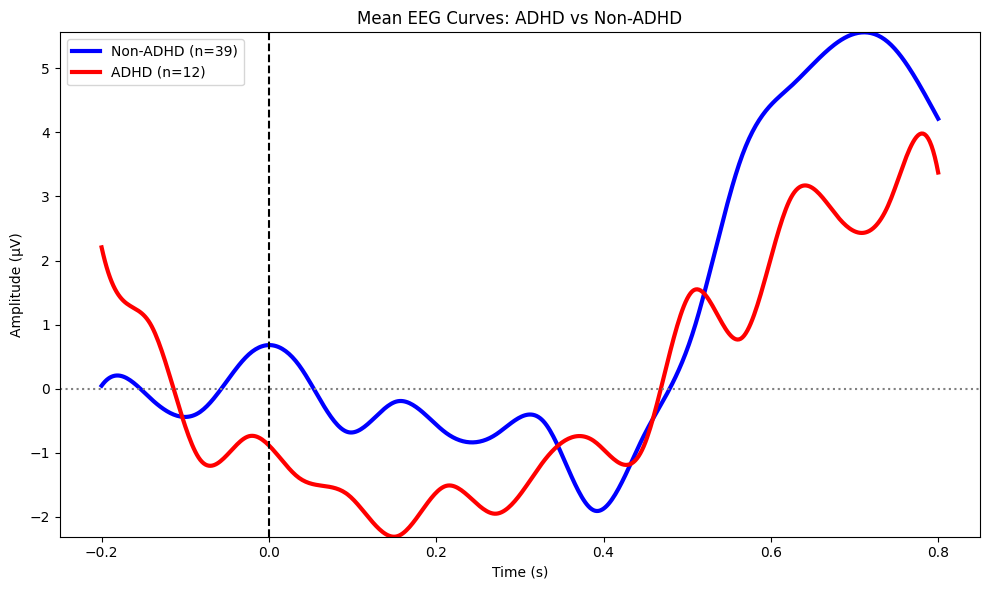

Saved: HT_02_mean_comparison.pdf


In [7]:
mean_adhd    = Y_adhd.mean(axis=1)
mean_nonadhd = Y_nonadhd.mean(axis=1)
ylim = (min(mean_adhd.min(), mean_nonadhd.min()),
        max(mean_adhd.max(), mean_nonadhd.max()))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_fine, mean_nonadhd, color='blue', linewidth=3,
        label=f'Non-ADHD (n={len(nonadhd_idx)})')
ax.plot(t_fine, mean_adhd,    color='red',  linewidth=3,
        label=f'ADHD (n={len(adhd_idx)})')
ax.axvline(0, linestyle='--', color='black')
ax.axhline(0, linestyle=':', color='grey')
ax.set_ylim(ylim)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Mean EEG Curves: ADHD vs Non-ADHD')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'HT_02_mean_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_02_mean_comparison.pdf')


## Test 1: Pointwise Z-test

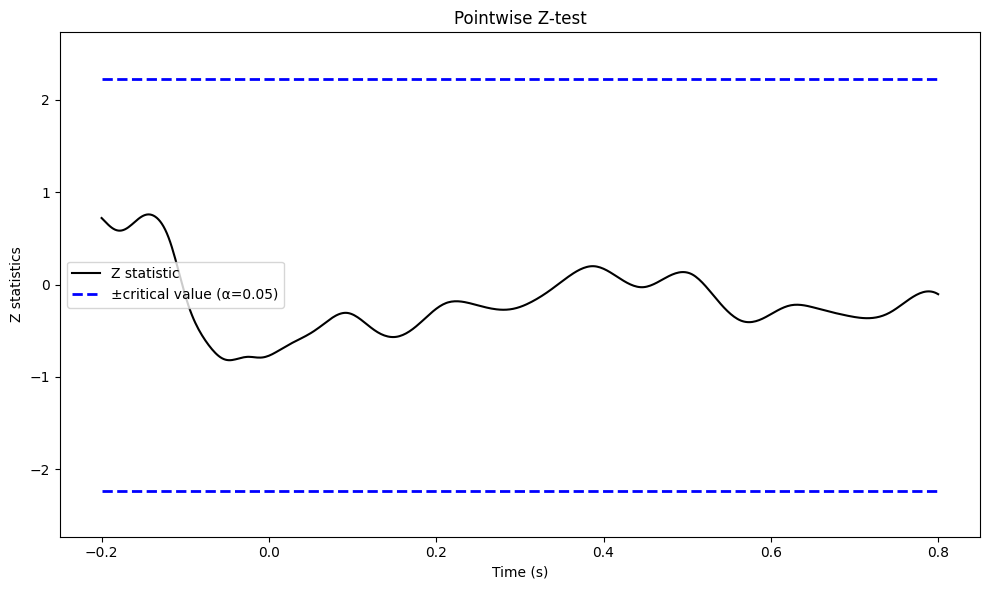

Saved: HT_03_pointwise_Ztest.pdf

=== Pointwise Z-test ===
Critical value: 2.2281
Max |Z|: 0.8186
Time points where |Z| > critical: 0 out of 501


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
stat_z = z_two_sample(x=Y_adhd, y=Y_nonadhd, t_seq=t_fine, ax=ax)
ax.set_title('Pointwise Z-test')
ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(out_dir / 'HT_03_pointwise_Ztest.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_03_pointwise_Ztest.pdf')

print('\n=== Pointwise Z-test ===')
crit = stat_z['params']['critical_value']
print(f'Critical value: {crit:.4f}')
print(f'Max |Z|: {np.max(np.abs(stat_z["statistics_pointwise"])):.4f}')
sig_points = np.sum(np.abs(stat_z['statistics_pointwise']) > crit)
print(f'Time points where |Z| > critical: {sig_points} out of {len(t_fine)}')


## Test 2: L2-norm test (naive)

In [9]:
stat_l2_naive = l2_stat_two_sample(x=Y_adhd, y=Y_nonadhd, t_seq=t_fine, method=1)
print('=== L2-norm test (naive) ===')
print(f'L2 statistic: {stat_l2_naive["statistics"]:.4f}')
print(f'p-value:      {stat_l2_naive["pvalue"]:.4f}')


=== L2-norm test (naive) ===
L2 statistic: 10879.6047
p-value:      0.9430


## Test 3: L2-norm test (bootstrap)

In [10]:
stat_l2_boot = l2_stat_two_sample(x=Y_adhd, y=Y_nonadhd, t_seq=t_fine,
                                   method=2, replications=500, random_state=42)
print('=== L2-norm test (bootstrap, 500 replications) ===')
print(f'L2 statistic: {stat_l2_boot["statistics"]:.4f}')
print(f'p-value:      {stat_l2_boot["pvalue"]:.4f}')


=== L2-norm test (bootstrap, 500 replications) ===
L2 statistic: 10879.6047
p-value:      0.7340


## Test 4: F-type test (naive)

In [11]:
stat_f_naive = f_stat_two_sample(x=Y_adhd, y=Y_nonadhd, t_seq=t_fine, method=1)
print('=== F-type test (naive) ===')
print(f'F statistic: {stat_f_naive["statistics"]:.4f}')
print(f'p-value:     {stat_f_naive["pvalue"]:.4f}')


=== F-type test (naive) ===
F statistic: 0.0818
p-value:     0.9429


## Test 5: F-type test (bootstrap)

In [12]:
stat_f_boot = f_stat_two_sample(x=Y_adhd, y=Y_nonadhd, t_seq=t_fine,
                                 method=2, replications=500, random_state=42)
print('=== F-type test (bootstrap, 500 replications) ===')
print(f'F statistic: {stat_f_boot["statistics"]:.4f}')
print(f'p-value:     {stat_f_boot["pvalue"]:.4f}')


=== F-type test (bootstrap, 500 replications) ===
F statistic: 0.0818
p-value:     0.7440


## Test 6: Permutation test

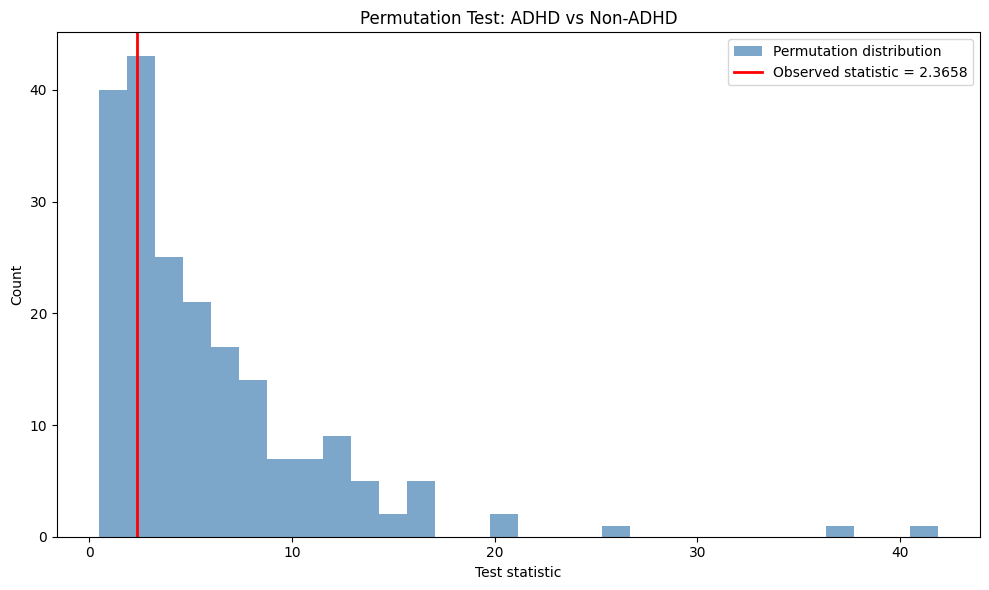

Saved: HT_04_permutation_test.pdf
p-value: 0.6950


In [13]:
def tperm_fd(x, y, t_seq, replications=200, random_state=None):
    """
    Permutation test for equality of two functional means.
    Python equivalent of fda::tperm.fd().
    Test statistic: integrated squared difference of means.
    """
    if random_state is not None:
        np.random.seed(random_state)

    n = x.shape[1]
    m = y.shape[1]
    combined = np.hstack([x, y])     # (k, n+m)

    def test_stat(a, b):
        diff = a.mean(axis=1) - b.mean(axis=1)
        return np.trapezoid(diff**2, t_seq)

    observed = test_stat(x, y)
    perm_stats = np.zeros(replications)

    for i in range(replications):
        perm     = np.random.permutation(n + m)
        x_perm   = combined[:, perm[:n]]
        y_perm   = combined[:, perm[n:]]
        perm_stats[i] = test_stat(x_perm, y_perm)

    pval = float(np.mean(perm_stats >= observed))
    return {'statistic': observed, 'pval': pval, 'perm_stats': perm_stats}

stat_perm = tperm_fd(Y_adhd, Y_nonadhd, t_fine, replications=200, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(stat_perm['perm_stats'], bins=30, color='steelblue', alpha=0.7,
        label='Permutation distribution')
ax.axvline(stat_perm['statistic'], color='red', linewidth=2,
           label=f'Observed statistic = {stat_perm["statistic"]:.4f}')
ax.set_xlabel('Test statistic')
ax.set_ylabel('Count')
ax.set_title('Permutation Test: ADHD vs Non-ADHD')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'HT_04_permutation_test.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_04_permutation_test.pdf')
print(f'p-value: {stat_perm["pval"]:.4f}')


## Summary

In [14]:
pvals = {
    'L2-norm test (naive)':      stat_l2_naive['pvalue'],
    'L2-norm test (bootstrap)':  stat_l2_boot['pvalue'],
    'F-type test (naive)':       stat_f_naive['pvalue'],
    'F-type test (bootstrap)':   stat_f_boot['pvalue'],
    'Permutation test':          stat_perm['pval'],
}

sig_level = 0.05
print('=' * 40)
print('     HYPOTHESIS TESTING SUMMARY')
print('=' * 40)
print('H0: mu_ADHD(t) = mu_nonADHD(t)')
print('H1: mu_ADHD(t) != mu_nonADHD(t)')
print(f'ADHD group:     n = {len(adhd_idx)}')
print(f'Non-ADHD group: n = {len(nonadhd_idx)}')
print('-' * 40)
for name, pval in pvals.items():
    print(f'{name:<35}  p = {pval:.4f}')
print('-' * 40)
print(f'Significance level: alpha = {sig_level}')
all_pvals = list(pvals.values())
if all(p > sig_level for p in all_pvals):
    print('Conclusion: FAIL TO REJECT H0.')
    print('No significant difference between ADHD and non-ADHD groups.')
elif all(p <= sig_level for p in all_pvals):
    print('Conclusion: REJECT H0.')
    print('Significant difference between ADHD and non-ADHD groups.')
else:
    print('Conclusion: MIXED RESULTS.')
    print('Some tests reject H0, others do not.')
print('=' * 40)


     HYPOTHESIS TESTING SUMMARY
H0: mu_ADHD(t) = mu_nonADHD(t)
H1: mu_ADHD(t) != mu_nonADHD(t)
ADHD group:     n = 12
Non-ADHD group: n = 39
----------------------------------------
L2-norm test (naive)                 p = 0.9430
L2-norm test (bootstrap)             p = 0.7340
F-type test (naive)                  p = 0.9429
F-type test (bootstrap)              p = 0.7440
Permutation test                     p = 0.6950
----------------------------------------
Significance level: alpha = 0.05
Conclusion: FAIL TO REJECT H0.
No significant difference between ADHD and non-ADHD groups.
